# Used Car Price Prediction — Data Analysis

## Objective

The goal of this project is to build a machine learning model that predicts the
price of a used car based on its available characteristics.

Before building the model, we will inspect and understand the dataset,
identify data quality issues, and prepare the data for machine learning.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [4]:
df=pd.read_csv("D:/used-car-price-prediction/data/cars.csv") 

In [5]:
df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [7]:
df.shape

(4009, 12)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


## Missing Value Analysis

In [30]:
missing=df.isnull().sum()

In [31]:
missing[missing>0]

Series([], dtype: int64)

In [32]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage[missing_percentage>0].sort_values(ascending=False)

Series([], dtype: float64)

In [38]:
df["fuel_type"] = df["fuel_type"].fillna("Unknown")
df["accident"] = df["accident"].fillna("Unknown")
df["clean_title"] = df["clean_title"].fillna("Unknown")

In [39]:
df.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

## Duplicate Records




In [33]:
duplicate=df.duplicated().sum()

In [34]:
duplicate

np.int64(0)

## Numerical Data Inspection

In [35]:
print("Model year")
print(df['model_year'].describe())

print("\n Millage examples")
print(df['milage'].head(10).tolist())

print("\nPrice examples:")
print(df["price"].head(10).tolist())

Model year
count    4009.000000
mean     2015.515590
std         6.104816
min      1974.000000
25%      2012.000000
50%      2017.000000
75%      2020.000000
max      2024.000000
Name: model_year, dtype: float64

 Millage examples
[51000.0, 34742.0, 22372.0, 88900.0, 9835.0, 136397.0, 84000.0, 242000.0, 23436.0, 34000.0]

Price examples:
[10300.0, 38005.0, 54598.0, 15500.0, 34999.0, 14798.0, 31000.0, 7300.0, 41927.0, 69950.0]


In [36]:
df[["milage", "price"]].dtypes

milage    float64
price     float64
dtype: object

In [37]:
df["milage"] = (
    df["milage"]
    .str.replace(" mi.", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

print(df[["milage", "price"]].dtypes)

AttributeError: Can only use .str accessor with string values, not floating

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   str    
 1   model         4009 non-null   str    
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     4009 non-null   str    
 5   engine        4009 non-null   str    
 6   transmission  4009 non-null   str    
 7   ext_col       4009 non-null   str    
 8   int_col       4009 non-null   str    
 9   accident      4009 non-null   str    
 10  clean_title   4009 non-null   str    
 11  price         4009 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 376.0 KB


## Baseline Model

In [41]:
X = df.drop("price", axis=1)
y = df["price"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (4009, 11)
Target: (4009,)


## Now Training 

In [43]:
from sklearn .model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("training data: ",X_train.shape)
print("test data: ",X_test.shape)




training data:  (3207, 11)
test data:  (802, 11)


In [47]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

baseline_prediction=y_train.mean()

baseline_mae=mean_absolute_error(y_test, [baseline_prediction]*len(y_test))
baseline_rmse=np.sqrt(
    mean_squared_error(y_test, [baseline_prediction]*len(y_test))
)
baseline_r2=r2_score(y_test, [baseline_prediction]*len(y_test))

print("Baseline_mae",baseline_mae)
print("baseline_rmse",baseline_mae)
print("r2_score",baseline_r2)

Baseline_mae 35276.1590714514
baseline_rmse 35276.1590714514
r2_score -0.0024909407219579904


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

categorical_features = X.select_dtypes(include=["str"]).columns
numeric_features = X.select_dtypes(exclude=["str"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression MAE:", mae)
print("Linear Regression RMSE:", rmse)
print("Linear Regression R²:", r2)

Linear Regression MAE: 25845.24904340145
Linear Regression RMSE: 137153.6714804965
Linear Regression R²: 0.07967101867416737


In [50]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Absolute_Error"] = comparison["Error"].abs()

comparison.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

,Actual,Predicted,Error,Absolute_Error
70,2954083.0,26213.043490,2.927870e+06,2.927870e+06
165,1950995.0,121055.151741,1.829940e+06,1.829940e+06
493,1599000.0,89153.162396,1.509847e+06,1.509847e+06
95,489995.0,53049.903262,4.369451e+05,4.369451e+05
548,429998.0,42303.953298,3.876940e+05,3.876940e+05


In [53]:
worst_indices = comparison["Absolute_Error"].nlargest(5).index

X_test.loc[worst_indices]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
693,Maserati,Quattroporte Base,2005,32000.0,Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,At least 1 accident or damage reported,Yes
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,Yes
3046,Porsche,Carrera GT Base,2005,4400.0,Gasoline,605.0HP 5.7L 10 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes
1061,Dodge,Viper GTC,2017,1389.0,Gasoline,645.0HP 8.4L 10 Cylinder Engine Gasoline Fuel,M/T,Black,Black,None reported,Yes
203,Ford,GT,2005,1897.0,Gasoline,5.4 Liter SC DOHC,Manual,White,–,None reported,Unknown


In [54]:
print(df["price"].describe())

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


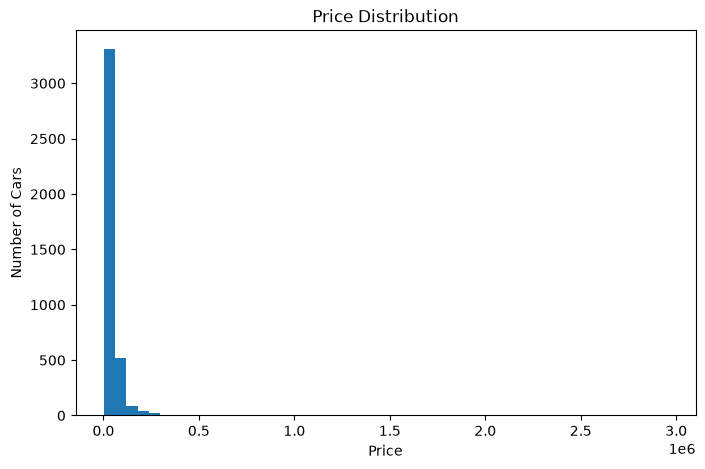

In [55]:
plt.figure(figsize=(8, 5))

plt.hist(df["price"], bins=50)

plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.title("Price Distribution")

plt.show()

In [56]:
from sklearn.compose import TransformedTargetRegressor

log_model = TransformedTargetRegressor(
    regressor=model,
    func=np.log1p,
    inverse_func=np.expm1
)

log_model.fit(X_train, y_train)

log_y_pred = log_model.predict(X_test)

log_mae = mean_absolute_error(y_test, log_y_pred)
log_rmse = np.sqrt(mean_squared_error(y_test, log_y_pred))
log_r2 = r2_score(y_test, log_y_pred)

print("Log-Transformed Linear Regression MAE:", log_mae)
print("Log-Transformed Linear Regression RMSE:", log_rmse)
print("Log-Transformed Linear Regression R²:", log_r2)

Log-Transformed Linear Regression MAE: 23934.688974129265
Log-Transformed Linear Regression RMSE: 140216.27050757626
Log-Transformed Linear Regression R²: 0.03811080625515906


In [57]:
df["engine_size"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)L", expand=False)
    .astype(float)
)

df["horsepower"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)HP", expand=False)
    .astype(float)
)

print(df[["engine", "engine_size", "horsepower"]].head())

                                              engine  engine_size  horsepower
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...          3.7       300.0
1                               3.8L V6 24V GDI DOHC          3.8         NaN
2                                     3.5 Liter DOHC          NaN         NaN
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...          3.5       354.0
4                         2.0L I4 16V GDI DOHC Turbo          2.0         NaN


In [58]:
df["engine_size"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)\s*(?:L|Liter)", expand=False)
    .astype(float)
)

df["horsepower"] = (
    df["engine"]
    .str.extract(r"(\d+(?:\.\d+)?)HP", expand=False)
    .astype(float)
)

print(df[["engine", "engine_size", "horsepower"]].head())
print("\nMissing values:")
print(df[["engine_size", "horsepower"]].isna().sum())

                                              engine  engine_size  horsepower
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...          3.7       300.0
1                               3.8L V6 24V GDI DOHC          3.8         NaN
2                                     3.5 Liter DOHC          3.5         NaN
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...          3.5       354.0
4                         2.0L I4 16V GDI DOHC Turbo          2.0         NaN

Missing values:
engine_size    217
horsepower     808
dtype: int64


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

categorical_features = X.select_dtypes(include=["str"]).columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", numeric_transformer, numeric_features)
    ]
)

print("Features:", X.shape)
print("Numeric features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Features: (4009, 13)
Numeric features: ['model_year', 'milage', 'engine_size', 'horsepower']
Categorical features: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression with Engine Features")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Linear Regression with Engine Features
MAE: 25353.263774140578
RMSE: 135564.82774065048
R²: 0.1008704400919519


In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regression")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Regression
MAE: 16433.099409808812
RMSE: 133553.38391637514
R²: 0.127354174197148
